In [65]:
import sys
sys.path.insert(0,'../scripts')
from pycap_for_PESTPP_MOU import postprocess_MOU, plot_pareto, prep_for_viz, create_viz_app, plot_pareto_with_scenarios
from pathlib import Path
from ipywidgets import interact, fixed
import yaml
import matplotlib.pyplot as plt
import pandas as pd

# Read in one of the configuration files and postprocess it. 
### The `config_file` should be your `secnario_name` + `".yml"` as assigned in the `05_MOU_setup_run.ipynb` notebook. 

In [66]:
configurations = ['depletion_q_baseline_0.0_1.0_0.01', 'depletion_q_Tmin10per_0.0_1.0_0.01', 'depletion_q_Tplus10per_0.0_1.0_0.01', 'depletion_q_Smin10per_0.0_1.0_0.01', 'depletion_q_Splus10per_0.0_1.0_0.01', 'depletion_q_Tmin1mag_0.0_1.0_0.01', 'depletion_q_Tplus1mag_0.0_1.0_0.01', 'depletion_q_Smin1mag_0.0_1.0_0.01']

configurations = ['depletion_q_baseline_0.0_1.0_0.01', 'depletion_q_baselinev2_0.0_1.0_0.01', 'depletion_q_baselinev3_0.0_1.0_0.01', 'depletion_q_baselinev4_0.0_1.0_0.01', 'depletion_q_baselinev5_0.0_1.0_0.01']

config = configurations[-1]  # Select the desired configuration
config_file = config + '.yml'

with open(Path('./configurations') / config_file,'r') as ifp:
    inpars = yaml.safe_load(ifp)
inpars

{'depletion_potential_threshold': 0.01,
 'objectives': 'depletion_q',
 'pump_lbound_fraction': 0.0,
 'pump_ubound_fraction': 1.0,
 'ref_q': 8.6,
 'run_path': '..\\pycap_runs\\pycap_pest\\run_depletion_q_baselinev5_0.0_1.0_0.01',
 'scenario_name': 'depletion_q_baselinev5_0.0_1.0_0.01'}

### Below, the `config_file` is processed, beginning the postprocessing

In [67]:
run_path = Path(inpars['run_path'])
run_name = inpars['scenario_name']
pareto_df = postprocess_MOU(run_name, run_path)

In [68]:
pareto_df

,generation,member,Depletion (cfs),Total Pumping (cfs),nsga2_front,nsga2_crowding_distance,spea2_unconstrained_fitness,spea2_constrained_fitness,is_feasible,feasible_distance
0,0,68,4.36164,36.303700,1,1.000000e+30,0.003680,0.003680,1,-999
1,0,152,4.78258,39.085358,1,1.000000e+30,0.004549,0.004549,1,-999
2,0,16,4.48927,38.467534,1,6.276820e-01,0.005091,0.005091,1,-999
3,0,130,4.69071,38.600100,1,5.036250e-01,0.007305,0.007305,1,-999
4,0,95,4.70127,38.900657,1,2.182550e-01,0.007305,0.007305,1,-999
...,...,...,...,...,...,...,...,...,...,...
9363,50,gen=50_member=8463_pso,1.69384,29.300651,1,7.117860e-03,0.002065,0.002065,1,-999
9365,50,gen=50_member=8442_pso,1.53189,27.945358,1,1.956550e-03,0.001504,0.001504,1,-999
9366,50,gen=50_member=8440_pso,1.72355,29.671167,1,6.488340e-03,0.002203,0.002203,1,-999
9369,50,gen=50_member=8557_pso,4.10670,36.762446,1,2.478290e-03,0.013918,0.013918,1,-999


### Next the evolution of the pareto frontier is plotted, over MOU iterations. Check out how the algorithm converges on a well-defined pareto tradeoff frontier

In [69]:
interact(plot_pareto,  currgen=(0,50,1), pareto_df=fixed(pareto_df));

interactive(children=(IntSlider(value=25, description='currgen', max=50), Output()), _dom_classes=('widget-int…

### Where do your scenarios line up? You can provide a list of scenarios that you ran in notebook #3 in the following function to plot a red "x" where each scenario plots up

### NOTE: This only works for the fish vs. receipts case!

In [70]:
dollars=False
# if 'dollar' in inpars['objectives']:
#     dollars = True
# if dollars:
#     plot_pareto_with_scenarios(pareto_df, scenarios=['LPR_Single_Run','LPR_Single_Run70','LPR_Single_Run90'])

### Finally, there is an interactive plot with the pareto frontier on the left and a map of corresponding "optimal" pumping rates on the right. 

### Note - if you get an error about ports being in conflict, change the `port=4242` argument to a different number than `4242`

In [71]:
pareto_df_final, dv_df =  prep_for_viz(pareto_df, 50, run_path, run_name, dollar_objective=dollars)
# app = create_viz_app(pareto_df_final, dv_df)
# app.run(port=4242)

### check out `pareto_df_final` and `dv_df`. What's in these datasets? What further analysis can you perform with this information?

In [72]:
dv_df.T.sample(10)

,well_1013,well_1302,well_1323,well_1486,well_1584,well_1589,well_1643,well_1683,well_1860,well_23610,...,well_93143,well_93349,well_93422,well_93423,well_93424,well_93469,well_93832,well_94302,well_94988,well_95068
gen=30_member=5121_pso,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.994965,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
gen=41_member=7024_pso,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
gen=32_member=5450_pso,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
gen=39_member=6555_pso,1.0,1.0,1.0,1.0,0.857856,1.0,1.0,1.0,1.0,0.974133,...,1.0,1.0,1.0,1.0,1.0,0.983415,1.0,1.0,1.0,1.0
gen=42_member=7187_pso,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
gen=45_member=7728_pso,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,0.973862,1.0,1.0,1.0,1.0
gen=48_member=8235_pso,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
gen=49_member=8354_pso,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.986181,...,0.99633,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
gen=48_member=8137_pso,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
gen=37_member=6363_pso,1.0,1.0,1.0,0.162808,0.068535,1.0,1.0,1.0,1.0,0.092885,...,0.48968,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0


In [94]:
dv_df.T.tail(1)

,well_1013,well_1302,well_1323,well_1486,well_1584,well_1589,well_1643,well_1683,well_1860,well_23610,...,well_93143,well_93349,well_93422,well_93423,well_93424,well_93469,well_93832,well_94302,well_94988,well_95068
geometry,POINT (-89.3453883 44.4873217),POINT (-89.4539046 44.5813718),POINT (-89.4508899 44.5219167),POINT (-89.4608233 44.5039967),POINT (-89.4647217 44.48),POINT (-89.4091941 44.4051847),POINT (-89.5335333 44.4174),POINT (-89.4090453 44.3906543),POINT (-89.4486378 44.5302783),POINT (-89.4409533 44.4574733),...,POINT (-89.528487 44.450128),POINT (-89.50594 44.41965),POINT (-89.30981 44.47068),POINT (-89.31012 44.4719),POINT (-89.31082 44.47132),POINT (-89.4464 44.4697),POINT (-89.2977 44.4647),POINT (-89.4835 44.4976),POINT (-89.396869 44.545632),POINT (-89.4462 44.4198)


In [73]:
pareto_df_final.columns

Index(['generation', 'member', 'Depletion (cfs)', 'Total Pumping (cfs)',
       'nsga2_front', 'nsga2_crowding_distance', 'spea2_unconstrained_fitness',
       'spea2_constrained_fitness', 'is_feasible', 'feasible_distance'],
      dtype='object')

In [74]:
pareto_df_final.sample(10)

,generation,member,Depletion (cfs),Total Pumping (cfs),nsga2_front,nsga2_crowding_distance,spea2_unconstrained_fitness,spea2_constrained_fitness,is_feasible,feasible_distance
9326,50,gen=35_member=5906_pso,2.75734,33.886989,1,0.001615,0.009380,0.009380,1,-999
9222,50,gen=34_member=5800_pso,4.38489,37.294046,1,0.004606,0.006871,0.006871,1,-999
9228,50,gen=42_member=7083_pso,2.79948,34.020892,1,0.004428,0.010273,0.010273,1,-999
9278,50,gen=36_member=6141_pso,3.88201,36.334001,1,0.003188,0.016370,0.016370,1,-999
9149,50,gen=42_member=7138_pso,4.05394,36.660849,1,0.006057,0.017368,0.017368,1,-999
9043,50,gen=43_member=7360_pso,1.88717,30.480154,1,0.013152,0.002739,0.002739,1,-999
9221,50,gen=37_member=6349_pso,3.59644,35.803737,1,0.004619,0.010486,0.010486,1,-999
9210,50,gen=45_member=7657_pso,2.32242,32.340980,1,0.004773,0.006609,0.006609,1,-999
9085,50,gen=34_member=5780_pso,2.43265,32.780118,1,0.008785,0.006673,0.006673,1,-999
9031,50,130,4.69071,38.600100,1,0.054395,0.001470,0.001470,1,-999


In [75]:
new_df = pareto_df_final.copy()
new_df.insert(2, "Streamflow (cfs)", 8.6 - new_df["Depletion (cfs)"])

In [76]:
new_df.columns

Index(['generation', 'member', 'Streamflow (cfs)', 'Depletion (cfs)',
       'Total Pumping (cfs)', 'nsga2_front', 'nsga2_crowding_distance',
       'spea2_unconstrained_fitness', 'spea2_constrained_fitness',
       'is_feasible', 'feasible_distance'],
      dtype='object')

In [77]:
# If we want to, we can save out the pareto tradeoff objectives results to a file. 
# Just change the name below and it will be a new copy!
new_df[['member', 'Total Pumping (cfs)', 'Streamflow (cfs)', 'Depletion (cfs)']].to_csv(f'{config}_tradeoff.csv')

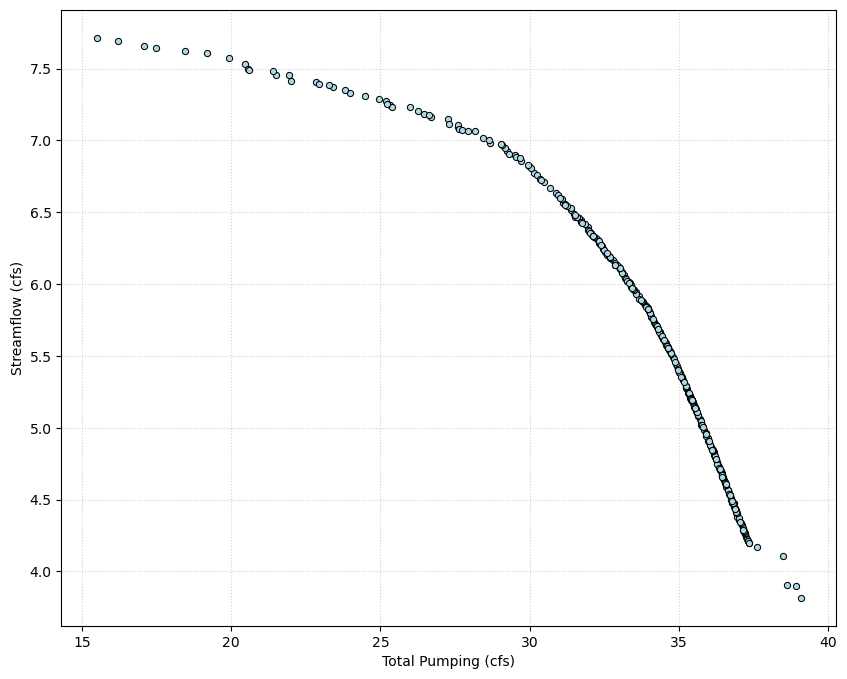

In [78]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(new_df["Total Pumping (cfs)"], new_df["Streamflow (cfs)"], marker="o", s=20, c="lightblue", edgecolors="black", linewidths=0.75)
ax.set_xlabel("Total Pumping (cfs)")
ax.set_ylabel("Streamflow (cfs)")
ax.grid(linestyle=":", alpha=0.6)
plt.show()

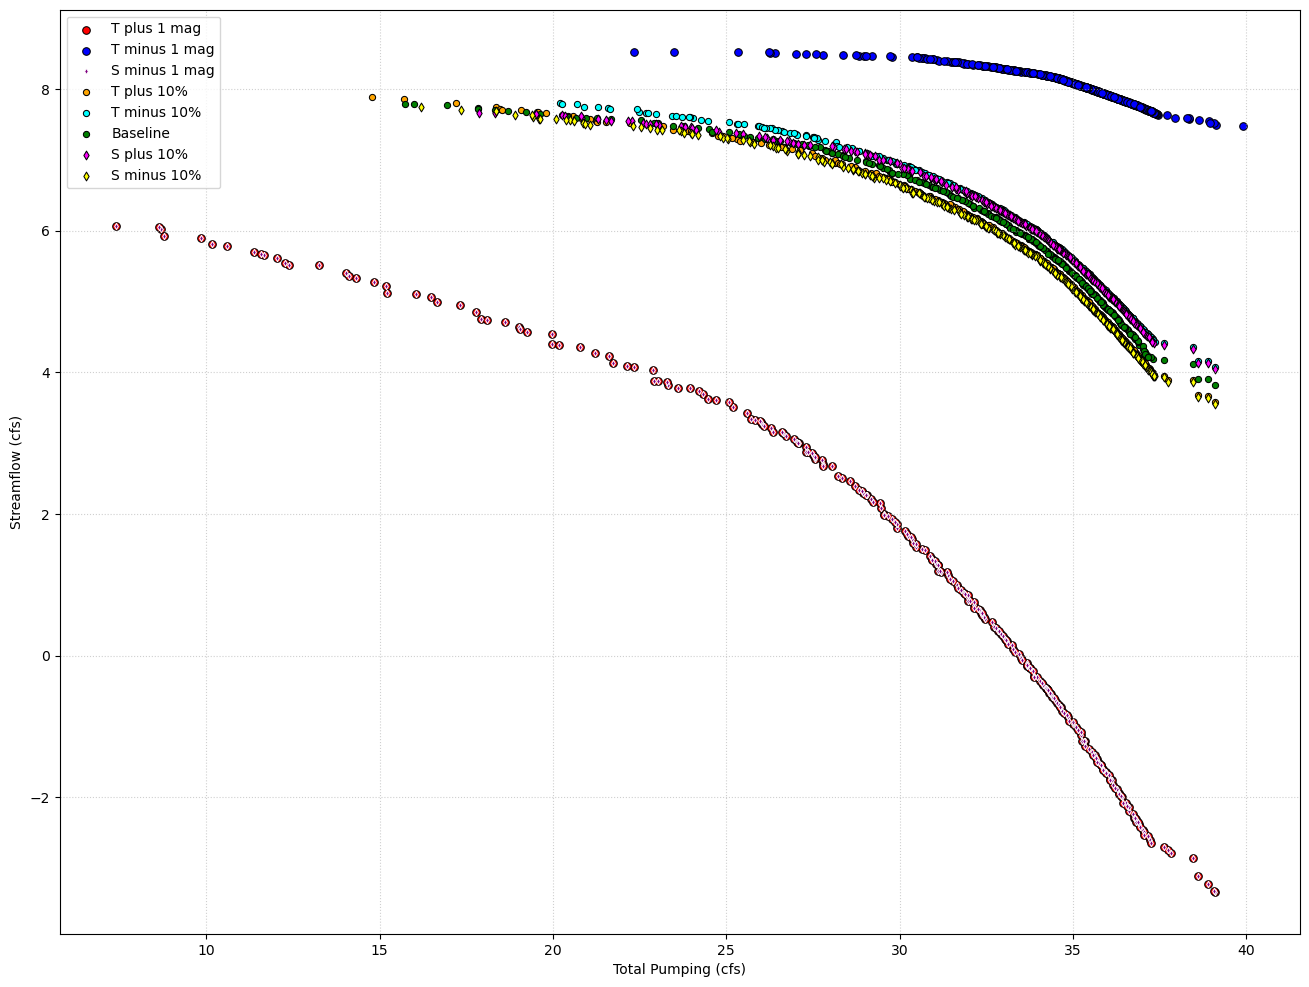

In [86]:
plusT1mag = pd.read_csv('depletion_q_Tplus1mag_0.0_1.0_0.01_tradeoff.csv')
minusT1mag = pd.read_csv('depletion_q_Tmin1mag_0.0_1.0_0.01_tradeoff.csv')
minusS1mag = pd.read_csv('depletion_q_Smin1mag_0.0_1.0_0.01_tradeoff.csv')
plusT10per = pd.read_csv('depletion_q_Tplus10per_0.0_1.0_0.01_tradeoff.csv')
minusT10per = pd.read_csv('depletion_q_Tmin10per_0.0_1.0_0.01_tradeoff.csv')
baseline = pd.read_csv('depletion_q_baseline_0.0_1.0_0.01_tradeoff.csv')
plusS10per = pd.read_csv('depletion_q_Splus10per_0.0_1.0_0.01_tradeoff.csv')
minusS10per = pd.read_csv('depletion_q_Smin10per_0.0_1.0_0.01_tradeoff.csv')

plt.figure(figsize=(16, 12))
plt.scatter(plusT1mag["Total Pumping (cfs)"], plusT1mag["Streamflow (cfs)"], marker="o", s=30, c="red", edgecolors="black", linewidths=0.75, label='T plus 1 mag')
plt.scatter(minusT1mag["Total Pumping (cfs)"], minusT1mag["Streamflow (cfs)"], marker="o", s=30, c="blue", edgecolors="black", linewidths=0.75, label='T minus 1 mag')
plt.scatter(minusS1mag["Total Pumping (cfs)"], minusS1mag["Streamflow (cfs)"], marker="d", s=10, c="purple", edgecolors="white", linewidths=0.75, label='S minus 1 mag')
plt.scatter(plusT10per["Total Pumping (cfs)"], plusT10per["Streamflow (cfs)"], marker="o", s=20, c="orange", edgecolors="black", linewidths=0.75, label='T plus 10%')
plt.scatter(minusT10per["Total Pumping (cfs)"], minusT10per["Streamflow (cfs)"], marker="o", s=20, c="cyan", edgecolors="black", linewidths=0.75, label='T minus 10%')
plt.scatter(baseline["Total Pumping (cfs)"], baseline["Streamflow (cfs)"], marker="o", s=20, c="green", edgecolors="black", linewidths=0.75, label='Baseline')
plt.scatter(plusS10per["Total Pumping (cfs)"], plusS10per["Streamflow (cfs)"], marker="d", s=20, c="magenta", edgecolors="black", linewidths=0.75, label='S plus 10%')
plt.scatter(minusS10per["Total Pumping (cfs)"], minusS10per["Streamflow (cfs)"], marker="d", s=20, c="yellow", edgecolors="black", linewidths=0.75, label='S minus 10%')
plt.xlabel("Total Pumping (cfs)")
plt.ylabel("Streamflow (cfs)")
plt.grid(linestyle=":", alpha=0.6)
# plt.xlim(25, 35)
# plt.ylim(3, 9)
plt.legend()

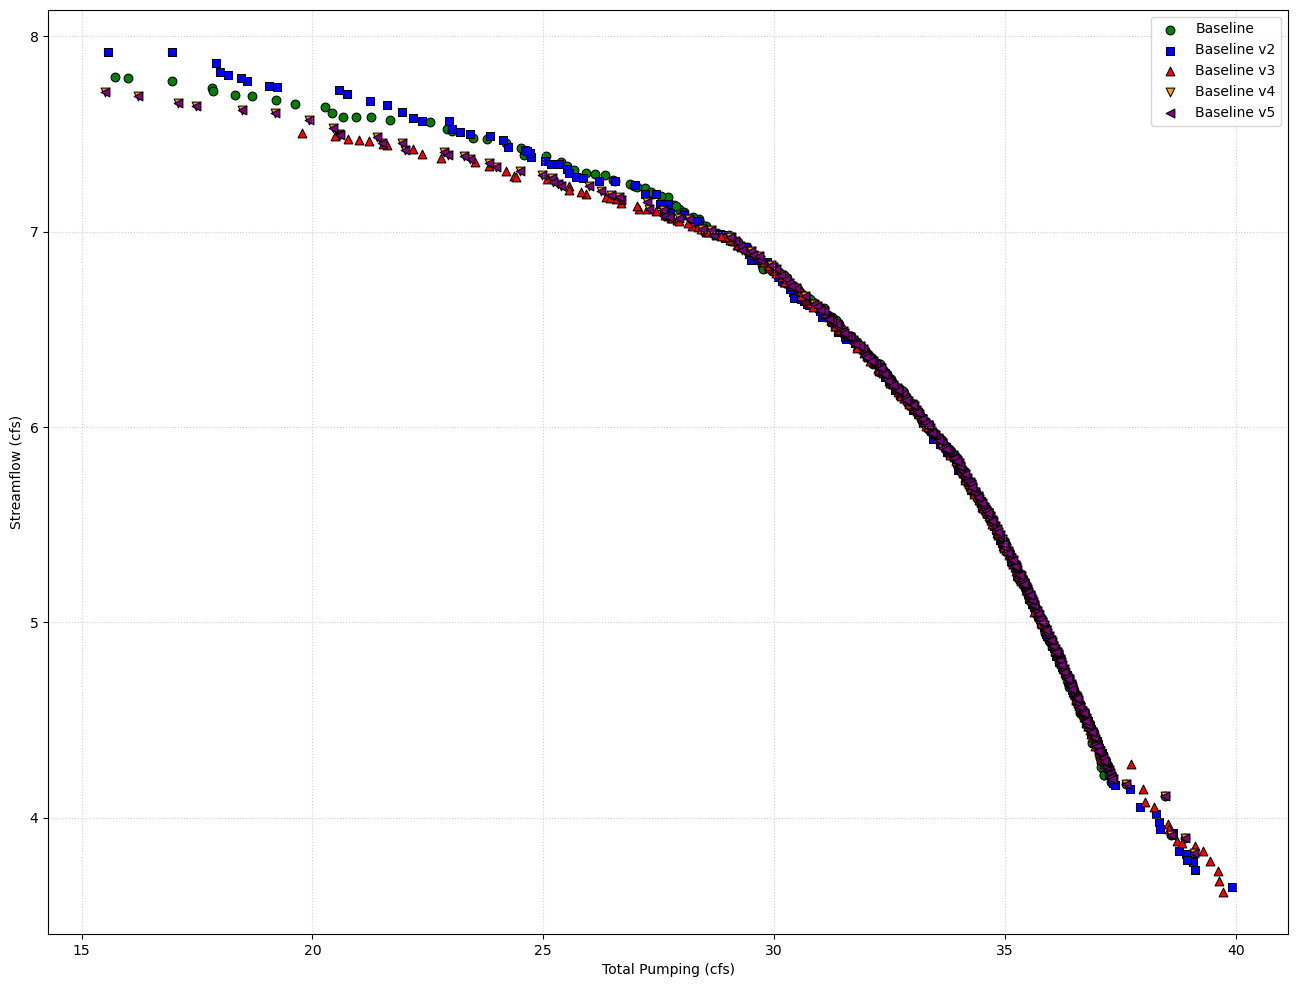

In [91]:
baseline1 = pd.read_csv('depletion_q_baseline_0.0_1.0_0.01_tradeoff.csv')
baseline2 = pd.read_csv('depletion_q_baselinev2_0.0_1.0_0.01_tradeoff.csv')
baseline3 = pd.read_csv('depletion_q_baselinev3_0.0_1.0_0.01_tradeoff.csv')
baseline4 = pd.read_csv('depletion_q_baselinev4_0.0_1.0_0.01_tradeoff.csv')
baseline5 = pd.read_csv('depletion_q_baselinev5_0.0_1.0_0.01_tradeoff.csv')

plt.figure(figsize=(16, 12))

plt.scatter(baseline1["Total Pumping (cfs)"], baseline1["Streamflow (cfs)"], marker="o", s=40, c="green", edgecolors="black", linewidths=0.75, label='Baseline')
plt.scatter(baseline2["Total Pumping (cfs)"], baseline2["Streamflow (cfs)"], marker="s", s=40, c="blue", edgecolors="black", linewidths=0.75, label='Baseline v2')
plt.scatter(baseline3["Total Pumping (cfs)"], baseline3["Streamflow (cfs)"], marker="^", s=40, c="red", edgecolors="black", linewidths=0.75, label='Baseline v3')
plt.scatter(baseline4["Total Pumping (cfs)"], baseline4["Streamflow (cfs)"], marker="v", s=40, c="orange", edgecolors="black", linewidths=0.75, label='Baseline v4')
plt.scatter(baseline5["Total Pumping (cfs)"], baseline5["Streamflow (cfs)"], marker="<", s=40, c="purple", edgecolors="black", linewidths=0.75, label='Baseline v5')

plt.xlabel("Total Pumping (cfs)")
plt.ylabel("Streamflow (cfs)")
plt.grid(linestyle=":", alpha=0.6)
# plt.xlim(25, 34)
# plt.ylim(6, 7.5)
# plt.xlim(30, 35)
# plt.ylim(6, 7)
# plt.xlim(20, 25)
# plt.ylim(7, 8)
plt.legend()